# CASP Example

In [2]:
"""
DataTypical Explorer
Finds and Explains Singificant Data Instances
"""
import os
import gc
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from joblib import Parallel, delayed
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from datatypical import DataTypical
import datatypical_viz
from datatypical_viz import significance_plot, heatmap, profile_plot, get_top_sample

warnings.filterwarnings("ignore")
np.random.seed(42)

In [3]:
# ============================================================
# [1] Load CASP data
# ============================================================

df = pd.read_csv(os.path.join("CASP.csv")) 

# FIX: Append the row name index to guarantee uniqueness
df['Protein_ID'] = df.apply(lambda row: f"SA{row['F1']:.1f}_NP{row['F2']:.1f}_F{row['F3']:.2f}_ix{int(row.name)}", axis=1) 

# Set the formula column as the DataFrame index 
df.set_index('Protein_ID', inplace=True) 

print(f"Dataset ready: {len(df):,} instances, label is RMSD")

Dataset ready: 45,730 instances, label is RMSD


In [4]:
# =====================================================================
# CONFIGURATION
# =====================================================================

dt = DataTypical(
    label_columns=['RMSD'],
    stereotype_column='RMSD',
    stereotype_target=-0.000001, 
    fast_mode=False,
    archetypal_method = 'aa',
    shapley_mode=True,
    shapley_top_n=len(df), 
    shapley_n_permutations=100,
    random_state=42,
    n_jobs = -1,
    verbose=True
)

# Fit and transform
results = dt.fit_transform(df)
print("✓ DataTypical results complete!")


Publication mode defaults:
  archetypal_method: aa
  shapley_n_permutations: 100
  shapley_top_n: 45730
  shapley_compute_formative: True
Auto-detected data_type: 'tabular'

Fitting archetypal: Archetypal Analysis (PCHA+ConvexHull)
  Computing 8 archetypes using PCHA (stable in 9D)...
  PCHA converged, variance explained: 99.68%
  Stored: W =(45730, 8), H =(8, 9), n_archetypes =8

Fitting prototypes: Facility Location (k=20)
  Selected 20 prototypes, knee at 1

Stereotypical configuration:
  Target column: 'RMSD'
  Target value: -1e-06
  Column range: [0.00, 21.00]
  Mean distance to target: 7.75

SHAPLEY DUAL-PERSPECTIVE ANALYSIS

[1] Computing Formative Instances (global perspective)...
    Using FULL dataset (required to measure structure)

  Computing Archetypal Formative (Cached Archetypes)...
    Samples: 45730, Features: 9
    Max permutations: 100
    100 perms, additivity error: 0.000000

  Computing Prototypical Formative (Coverage)...
    Samples: 45730, Features: 9
    Max

In [5]:
df

,RMSD,F1,F2,F3,F4,F5,F6,F7,F8,F9
Protein_ID,,,,,,,,,,
SA13558.3_NP4305.4_F0.32_ix0,17.284,13558.30,4305.35,0.31754,162.1730,1.872791e+06,215.3590,4287.87,102,27.0302
SA6192.0_NP1623.2_F0.26_ix1,6.021,6191.96,1623.16,0.26213,53.3894,8.034467e+05,87.2024,3328.91,39,38.5468
SA7726.0_NP1726.3_F0.22_ix2,9.275,7725.98,1726.28,0.22343,67.2887,1.075648e+06,81.7913,2981.04,29,38.8119
SA8424.6_NP2368.2_F0.28_ix3,15.851,8424.58,2368.25,0.28111,67.8325,1.210472e+06,109.4390,3248.22,70,39.0651
SA7460.8_NP1736.9_F0.23_ix4,7.962,7460.84,1736.94,0.23280,52.4123,1.021020e+06,94.5234,2814.42,41,39.9147
...,...,...,...,...,...,...,...,...,...,...
SA8037.1_NP2777.7_F0.35_ix45725,3.762,8037.12,2777.68,0.34560,64.3390,1.105797e+06,112.7460,3384.21,84,36.8036
SA7978.8_NP2508.6_F0.31_ix45726,6.521,7978.76,2508.57,0.31440,75.8654,1.116725e+06,102.2770,3974.52,54,36.0470
SA7726.6_NP2489.6_F0.32_ix45727,10.356,7726.65,2489.58,0.32220,70.9903,1.076560e+06,103.6780,3290.46,46,37.4718


In [6]:
results

,RMSD,F1,F2,F3,F4,F5,F6,F7,F8,F9,archetypal_rank,prototypical_rank,stereotypical_rank,archetypal_shapley_rank,prototypical_shapley_rank,stereotypical_shapley_rank
Protein_ID,,,,,,,,,,,,,,,,
SA13558.3_NP4305.4_F0.32_ix0,17.284,13558.30,4305.35,0.31754,162.1730,1.872791e+06,215.3590,4287.87,102,27.0302,0.404517,0.817264,0.176913,0.136577,0.091835,0.613640
SA6192.0_NP1623.2_F0.26_ix1,6.021,6191.96,1623.16,0.26213,53.3894,8.034467e+05,87.2024,3328.91,39,38.5468,0.444533,0.875226,0.713272,0.136577,0.091841,0.618977
SA7726.0_NP1726.3_F0.22_ix2,9.275,7725.98,1726.28,0.22343,67.2887,1.075648e+06,81.7913,2981.04,29,38.8119,0.514708,0.826827,0.558312,0.136577,0.091845,0.616989
SA8424.6_NP2368.2_F0.28_ix3,15.851,8424.58,2368.25,0.28111,67.8325,1.210472e+06,109.4390,3248.22,70,39.0651,0.569469,0.831675,0.245155,0.136577,0.091839,0.615396
SA7460.8_NP1736.9_F0.23_ix4,7.962,7460.84,1736.94,0.23280,52.4123,1.021020e+06,94.5234,2814.42,41,39.9147,0.574976,0.833945,0.620839,0.136577,0.091840,0.617941
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SA8037.1_NP2777.7_F0.35_ix45725,3.762,8037.12,2777.68,0.34560,64.3390,1.105797e+06,112.7460,3384.21,84,36.8036,0.425038,0.781672,0.820849,0.136577,0.091859,0.619845
SA7978.8_NP2508.6_F0.31_ix45726,6.521,7978.76,2508.57,0.31440,75.8654,1.116725e+06,102.2770,3974.52,54,36.0470,0.669208,0.797245,0.689461,0.136577,0.091839,0.619022
SA7726.6_NP2489.6_F0.32_ix45727,10.356,7726.65,2489.58,0.32220,70.9903,1.076560e+06,103.6780,3290.46,46,37.4718,0.549987,0.819155,0.506834,0.136577,0.091871,0.617147


## Archetypes


 Creating significance plot...
    ✓ Saved: arch_significance_casp.png


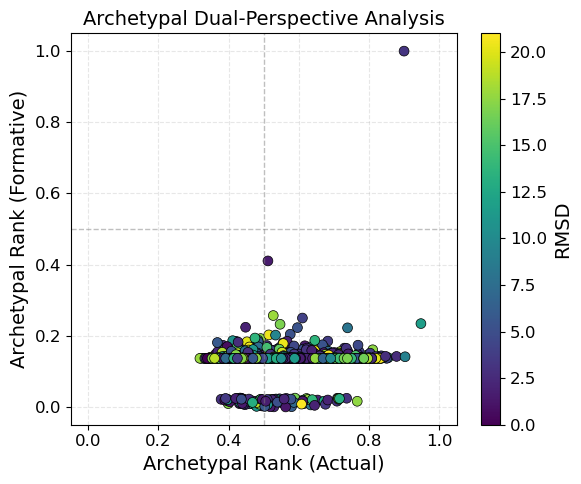

In [8]:
# ============================================================================
# Example 1: Archetypal Significance Plot (Dual-Perspective Scatter)
# ============================================================================
print("\n Creating significance plot...")

ax = significance_plot(
    results,
    significance='archetypal',
    color_by='RMSD',
    quadrant_lines=True,
    quadrant_threshold = (0.5,0.5)
)
ax.figure.savefig('arch_significance_casp.png', dpi=300, bbox_inches='tight')
print("    ✓ Saved: arch_significance_casp.png")


 Creating archetypal explanations heatmap...
    ✓ Saved: arch_heatmap_casp.png


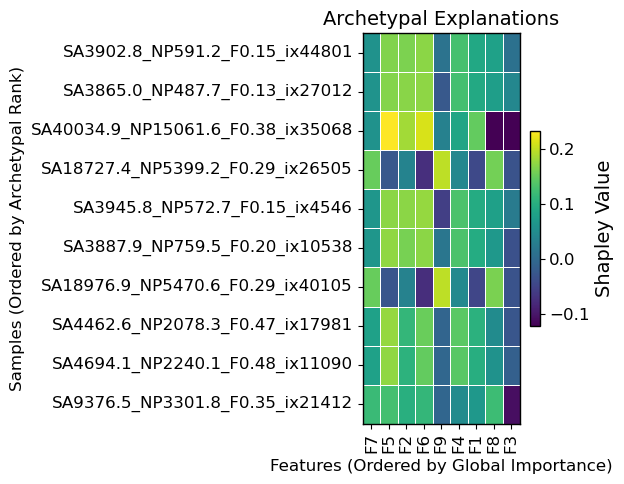

In [9]:
# ============================================================================
# Example 2: Heatmap - Archetypal Explanations
# ============================================================================
print("\n Creating archetypal explanations heatmap...")

ax = heatmap(
    dt,
    results=results,
    significance='archetypal', 
    order='actual',
    top_n=10
)
ax.figure.savefig('arch_heatmap_casp.png', dpi=300, bbox_inches='tight')
print("    ✓ Saved: arch_heatmap_casp.png")



 Creating archetypal profile plot...
    Top archetype: SA3902.8_NP591.2_F0.15_ix44801
RMSD                              11.686000
F1                              3902.800000
F2                               591.180000
F3                                 0.151470
F4                                30.961900
F5                            543826.840800
F6                                42.269300
F7                              1727.030000
F8                                 1.000000
F9                                46.546400
archetypal_rank                    0.948197
prototypical_rank                  0.662624
stereotypical_rank                 0.443497
archetypal_shapley_rank            0.234236
prototypical_shapley_rank          0.091822
stereotypical_shapley_rank         0.616805
Name: SA3902.8_NP591.2_F0.15_ix44801, dtype: float64
    ✓ Saved: arch_profile_casp.png


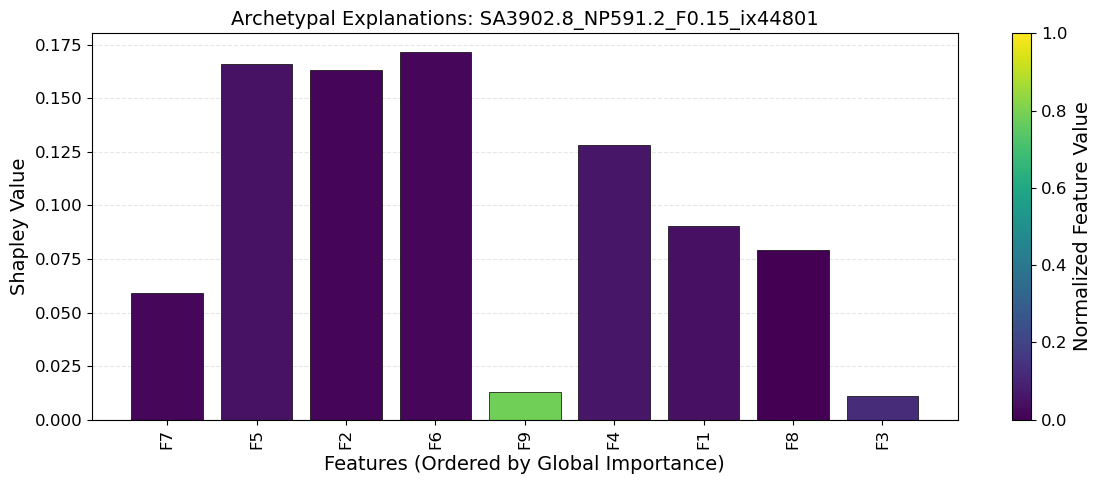

In [10]:
# ============================================================================
# Example 3a: Profile Plot - Top Archetype
# ============================================================================
print("\n Creating archetypal profile plot...")

top_arch_idx = results['archetypal_rank'].idxmax()
print(f"    Top archetype: {top_arch_idx}\n{results.loc[top_arch_idx]}")

ax = profile_plot(
    dt,
    sample_idx=top_arch_idx,
    significance='archetypal', 
    order='global'
)
ax.figure.savefig('arch_profile_casp.png', dpi=300, bbox_inches='tight')
print("    ✓ Saved: arch_profile_casp.png")



 Creating archetypal profile plot...
    Top formative archetype: SA40034.9_NP15061.6_F0.38_ix35068
RMSD                          3.272000e+00
F1                            4.003490e+04
F2                            1.506160e+04
F3                            3.762100e-01
F4                            3.112140e+02
F5                            5.472011e+06
F6                            5.984080e+02
F7                            8.617680e+03
F8                            1.450000e+02
F9                            4.654640e+01
archetypal_rank               9.001361e-01
prototypical_rank             4.772339e-01
stereotypical_rank            8.441830e-01
archetypal_shapley_rank       1.000000e+00
prototypical_shapley_rank     9.167947e-02
stereotypical_shapley_rank    6.221160e-01
Name: SA40034.9_NP15061.6_F0.38_ix35068, dtype: float64
    ✓ Saved: arch_form_casp.png


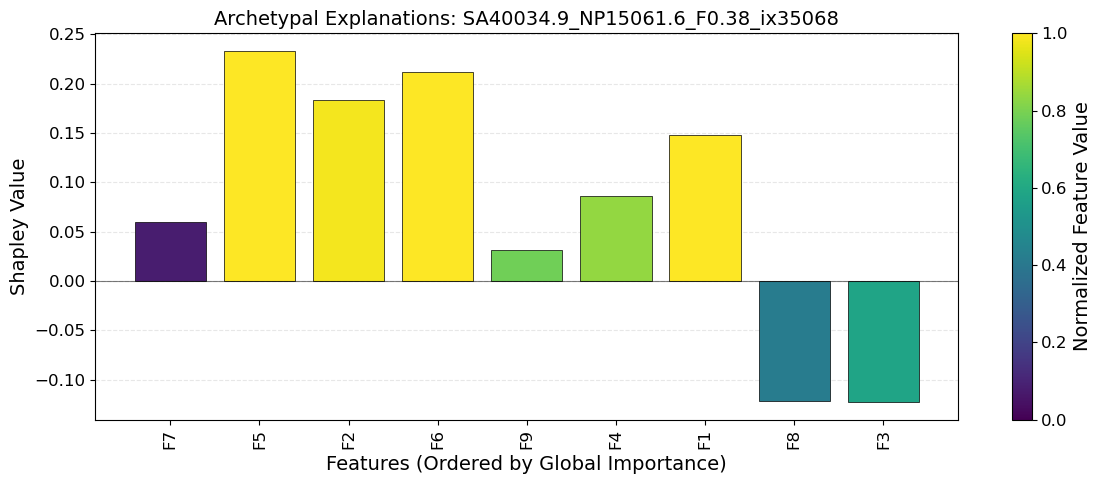

In [11]:
# ============================================================================
# Example 3b: Profile Plot - Top Formative Archetype
# ============================================================================
print("\n Creating archetypal profile plot...")

top_arch_idx = results['archetypal_shapley_rank'].idxmax()
print(f"    Top formative archetype: {top_arch_idx}\n{results.loc[top_arch_idx]}")

ax = profile_plot(
    dt,
    sample_idx=top_arch_idx,
    significance='archetypal', 
    order='global'
)
ax.figure.savefig('arch_form_casp.png', dpi=300, bbox_inches='tight')
print("    ✓ Saved: arch_form_casp.png")


## Prototypes


 Creating significance plot...
    ✓ Saved: proto_significance_casp.png


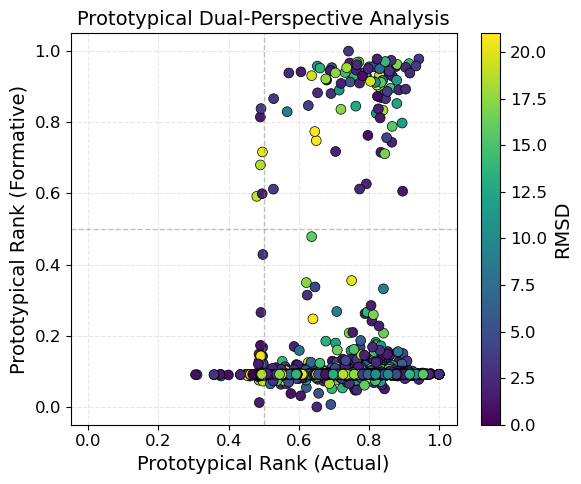

In [13]:
# ============================================================================
# Example 4: Prototypical Significance Plot (Dual-Perspective Scatter)
# ============================================================================
print("\n Creating significance plot...")

ax = significance_plot(
    results,
    significance='prototypical',
    color_by='RMSD',
    quadrant_lines=True,
    quadrant_threshold = (0.5,0.5)
)
ax.figure.savefig('proto_significance_casp.png', dpi=300, bbox_inches='tight')
print("    ✓ Saved: proto_significance_casp.png")


 Creating prototypical explanations heatmap...
    ✓ Saved: proto_heatmap_casp.png


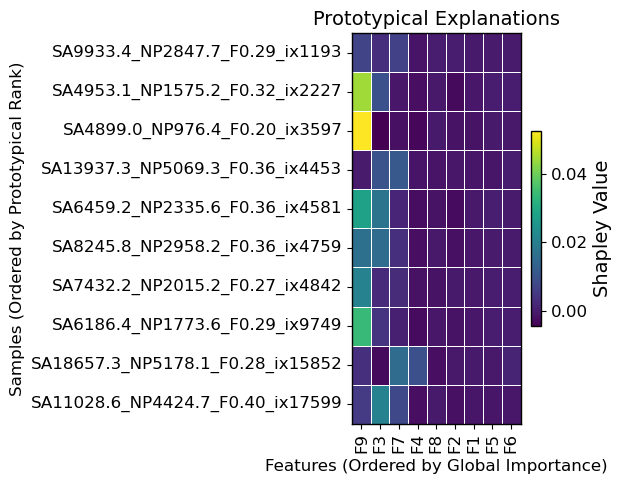

In [14]:
# ============================================================================
# Example 5: Heatmap - Prototypical Explanations
# ============================================================================
print("\n Creating prototypical explanations heatmap...")

ax = heatmap(
    dt,
    results=results,
    significance='prototypical', 
    order='actual',
    top_n=10
)
ax.figure.savefig('proto_heatmap_casp.png', dpi=300, bbox_inches='tight')
print("    ✓ Saved: proto_heatmap_casp.png")



 Creating prototpyical profile plot...
    Top prototype: SA9933.4_NP2847.7_F0.29_ix1193
RMSD                          2.217000e+00
F1                            9.933380e+03
F2                            2.847700e+03
F3                            2.866700e-01
F4                            9.943280e+01
F5                            1.360200e+06
F6                            1.452930e+02
F7                            3.871260e+03
F8                            1.190000e+02
F9                            3.296380e+01
archetypal_rank               5.167938e-01
prototypical_rank             1.000000e+00
stereotypical_rank            8.944235e-01
archetypal_shapley_rank       1.365770e-01
prototypical_shapley_rank     9.187860e-02
stereotypical_shapley_rank    6.205063e-01
Name: SA9933.4_NP2847.7_F0.29_ix1193, dtype: float64
    ✓ Saved: proto_profile_casp.png


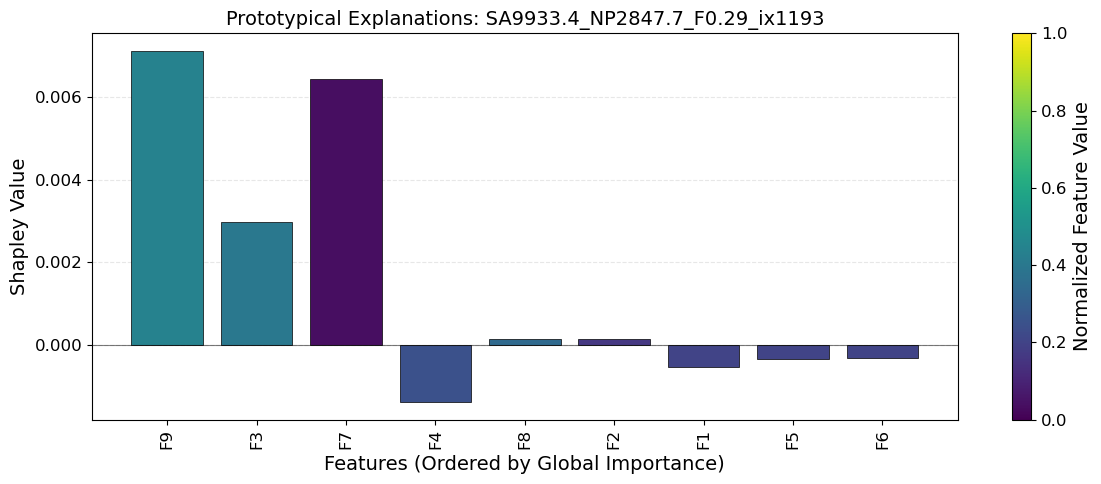

In [15]:
# ============================================================================
# Example 6a: Profile Plot - Top Prototype
# ============================================================================
print("\n Creating prototpyical profile plot...")

top_proto_idx = results['prototypical_rank'].idxmax()
print(f"    Top prototype: {top_proto_idx}\n{results.loc[top_proto_idx]}")

ax = profile_plot(
    dt,
    sample_idx=top_proto_idx,
    significance='prototypical', 
    order='global'
)
ax.figure.savefig('proto_profile_casp.png', dpi=300, bbox_inches='tight')
print("    ✓ Saved: proto_profile_casp.png")



 Creating prototpyical profile plot...
    Top formative prototype: SA10946.3_NP3197.9_F0.29_ix20295
RMSD                          3.401000e+00
F1                            1.094630e+04
F2                            3.197950e+03
F3                            2.921400e-01
F4                            1.282980e+02
F5                            1.520686e+06
F6                            1.521390e+02
F7                            4.881560e+03
F8                            8.500000e+01
F9                            2.914000e+01
archetypal_rank               7.287085e-01
prototypical_rank             7.417835e-01
stereotypical_rank            8.380399e-01
archetypal_shapley_rank       1.365770e-01
prototypical_shapley_rank     1.000000e+00
stereotypical_shapley_rank    6.263442e-01
Name: SA10946.3_NP3197.9_F0.29_ix20295, dtype: float64
    ✓ Saved: proto_form_casp.png


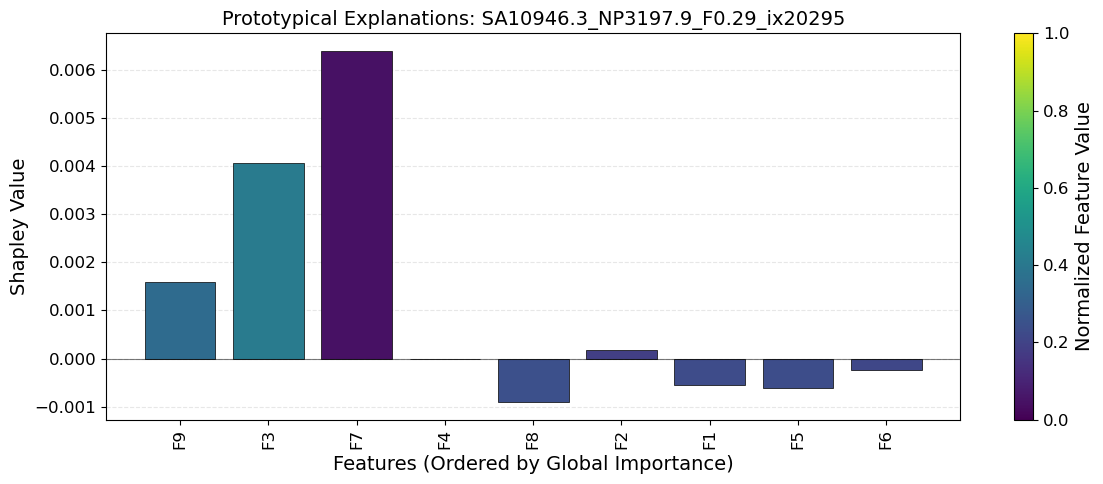

In [16]:
# ============================================================================
# Example 6b: Profile Plot - Top Formative Prototype
# ============================================================================
print("\n Creating prototpyical profile plot...")

top_proto_idx = results['prototypical_shapley_rank'].idxmax()
print(f"    Top formative prototype: {top_proto_idx}\n{results.loc[top_proto_idx]}")

ax = profile_plot(
    dt,
    sample_idx=top_proto_idx,
    significance='prototypical', 
    order='global'
)
ax.figure.savefig('proto_form_casp.png', dpi=300, bbox_inches='tight')
print("    ✓ Saved: proto_form_casp.png")


## Stereotypes


 Creating significance plot...
    ✓ Saved: stereo_significance_casp.png


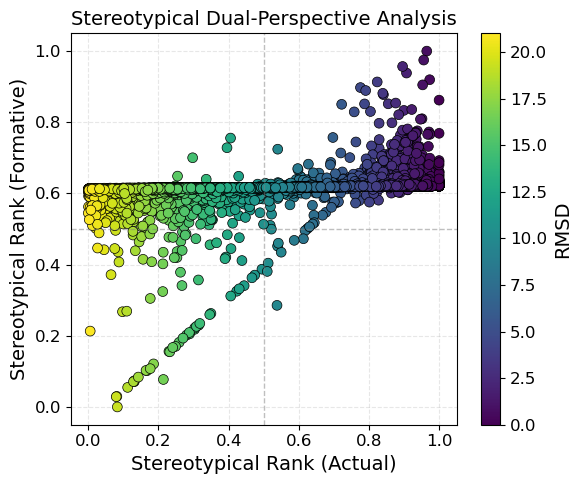

In [18]:
# ============================================================================
# Example 7: Stereotypical Significance Plot (Dual-Perspective Scatter)
# ============================================================================
print("\n Creating significance plot...")

ax = significance_plot(
    results,
    significance='stereotypical',
    color_by='RMSD',
    quadrant_lines=True,
    quadrant_threshold = (0.5,0.5)
)
ax.figure.savefig('stereo_significance_casp.png', dpi=300, bbox_inches='tight')
print("    ✓ Saved: stereo_significance_casp.png")


 Creating stereotypical explanations heatmap...
    ✓ Saved: stereo_heatmap_casp.png


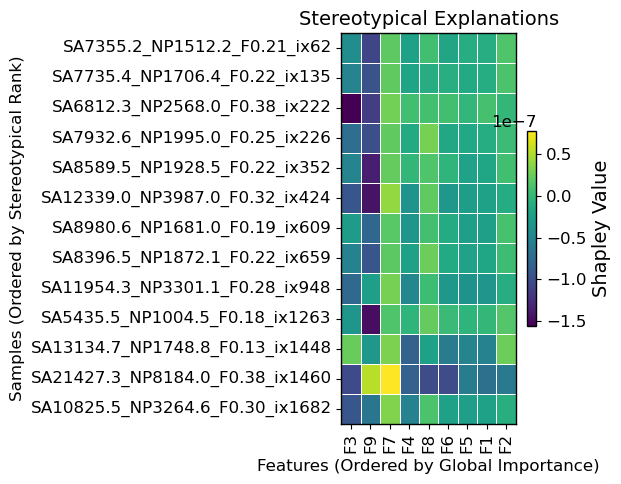

In [19]:
# ============================================================================
# Example 8: Heatmap - Stereotypical Explanations
# ============================================================================
print("\n Creating stereotypical explanations heatmap...")

ax = heatmap(
    dt,
    results=results,
    significance='stereotypical', 
    order='actual',
    top_n=13
)
ax.figure.savefig('stereo_heatmap_casp.png', dpi=300, bbox_inches='tight')
print("    ✓ Saved: stereo_heatmap_casp.png")



 Creating stereotypical profile plot...
    Top stereotype: SA7355.2_NP1512.2_F0.21_ix62
RMSD                               0.000000
F1                              7355.240000
F2                              1512.220000
F3                                 0.205590
F4                                75.011400
F5                            993282.853800
F6                               115.556000
F7                              3464.680000
F8                                27.000000
F9                                36.682800
archetypal_rank                    0.453591
prototypical_rank                  0.774621
stereotypical_rank                 1.000000
archetypal_shapley_rank            0.136952
prototypical_shapley_rank          0.108848
stereotypical_shapley_rank         0.660900
Name: SA7355.2_NP1512.2_F0.21_ix62, dtype: float64
    ✓ Saved: stereo_profile_casp.png


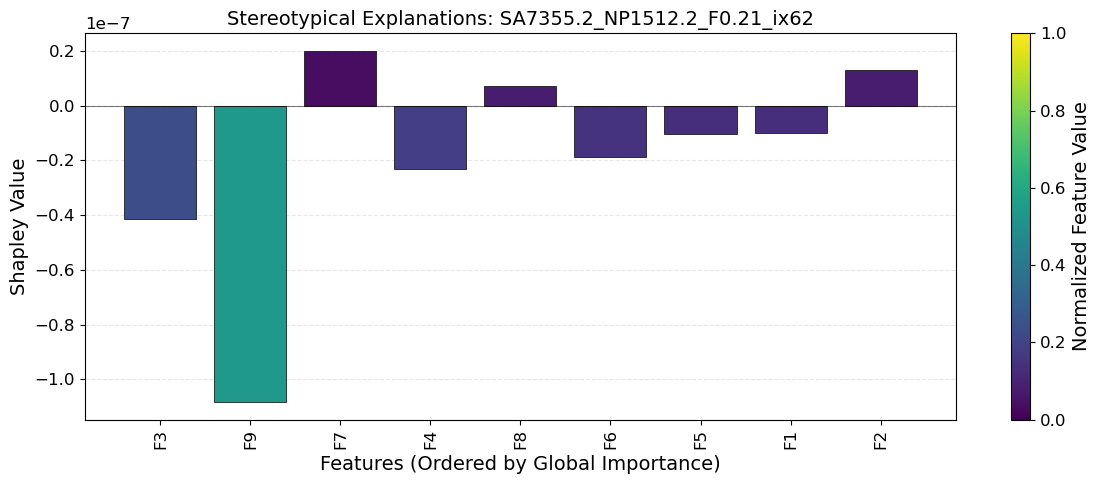

In [20]:
# ============================================================================
# Example 9a: Profile Plot - Top Stereotype
# ============================================================================
print("\n Creating stereotypical profile plot...")

top_stereo_idx = results['stereotypical_rank'].idxmax()
print(f"    Top stereotype: {top_stereo_idx}\n{results.loc[top_stereo_idx]}")

ax = profile_plot(
    dt,
    sample_idx=top_stereo_idx,
    significance='stereotypical', 
    order='global'
)
ax.figure.savefig('stereo_profile_casp.png', dpi=300, bbox_inches='tight')
print("    ✓ Saved: stereo_profile_casp.png")



 Creating stereotypical formative profile plot...
    Top formative stereotype: SA10794.7_NP2705.6_F0.25_ix11137
RMSD                          7.390000e-01
F1                            1.079470e+04
F2                            2.705580e+03
F3                            2.506300e-01
F4                            1.372000e+02
F5                            1.504694e+06
F6                            1.687660e+02
F7                            4.689670e+03
F8                            1.750000e+02
F9                            2.878870e+01
archetypal_rank               4.877293e-01
prototypical_rank             6.310100e-01
stereotypical_rank            9.648078e-01
archetypal_shapley_rank       1.365770e-01
prototypical_shapley_rank     9.184081e-02
stereotypical_shapley_rank    1.000000e+00
Name: SA10794.7_NP2705.6_F0.25_ix11137, dtype: float64
    ✓ Saved: stereo_form_casp.png


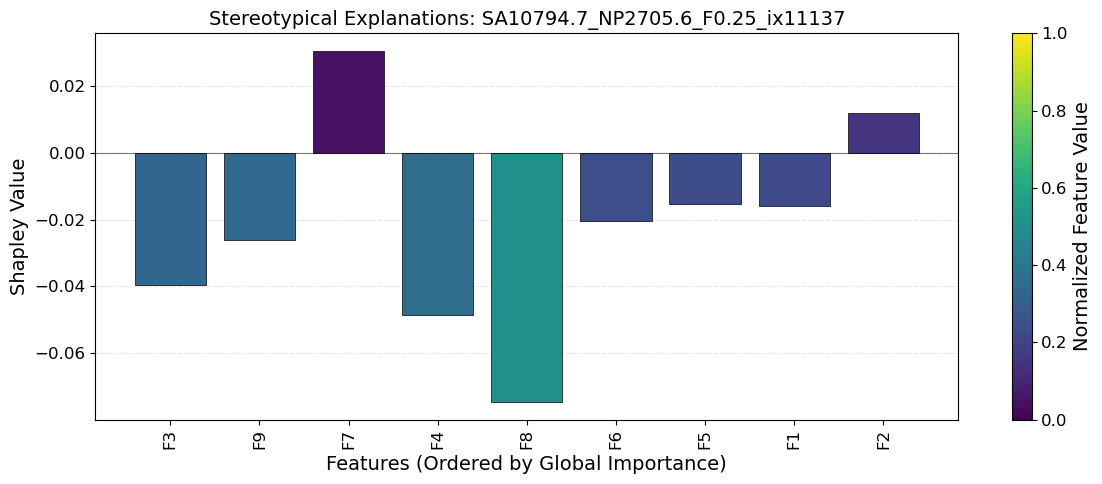

In [21]:
# ============================================================================
# Example 9b: Profile Plot - Top Formative Stereotype
# ============================================================================
print("\n Creating stereotypical formative profile plot...")

top_stereo_idx = results['stereotypical_shapley_rank'].idxmax()
print(f"    Top formative stereotype: {top_stereo_idx}\n{results.loc[top_stereo_idx]}")

ax = profile_plot(
    dt,
    sample_idx=top_stereo_idx,
    significance='stereotypical', 
    order='global'
)
ax.figure.savefig('stereo_form_casp.png', dpi=300, bbox_inches='tight')
print("    ✓ Saved: stereo_form_casp.png")


In [22]:
import pickle

# Save the model
with open('casp_dt.pkl', 'wb') as file:
    pickle.dump(dt, file)

# Save the results
with open('casp_results.pkl', 'wb') as file:
    pickle.dump(results, file)

# # Load the model
# with open('casp_dt.pkl', 'rb') as file:
#     dt = pickle.load(file)

# # Load the results
# with open('casp_results.pkl', 'rb') as file:
#     results = pickle.load(file)